In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from src import *

# Probabilitiy distributions


In [3]:
# random input probabilitiy
Px = np.random.RandomState(42).rand(2**9)
Px /= Px.sum()

# random pixel-level output probability
Pyi = np.array([np.random.RandomState(x).rand(9).reshape(3,3) for x in range(2**9)])

# image-level output probability derived from pixel-level probabilities
Py = np.array([np.array([np.where(int2img(y), Pyi[x], 1 - Pyi[x]).prod() for y in range(2**9)]) for x in range(2**9)])

# Pixel-wise model

In [4]:
def get_hatPs_h(scale=0.5):
    # pixel-level probability is predicted with a gaussian noise at the logits
    def hatpyi(x):
        z = sp.special.logit(Pyi[x])
        zhat = np.random.RandomState(x).normal(z, scale=scale)
        return sp.special.expit(zhat)

    # I think the following is more efficient, but I'm not risking it now
    # def pyhat(y, x):
    #     return np.abs((1-int2img(y)) - pyihat(x)).prod()

    hatPyi = [hatpyi(x) for x in np.arange(2**9)]
    hatPy = [np.array([np.where(int2img(y), pyi, 1 - pyi).prod() for y in np.arange(2**9)]) for pyi in hatPyi]

    # The model constructs the prediction by applying a threshold at the
    # predicted probabilities.
    def h(x):
        yhat_img = (hatPyi[x] > 0.5).astype("uint8")
        yhat = np.sum(2**np.arange(9) * yhat_img.reshape(-1))
        return yhat
    
    return hatPy, hatPyi, h

## Losses

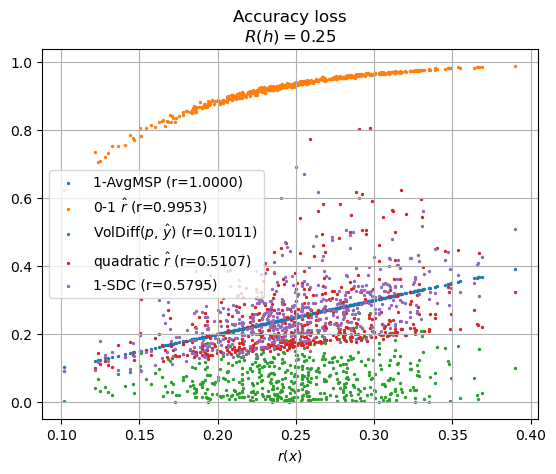

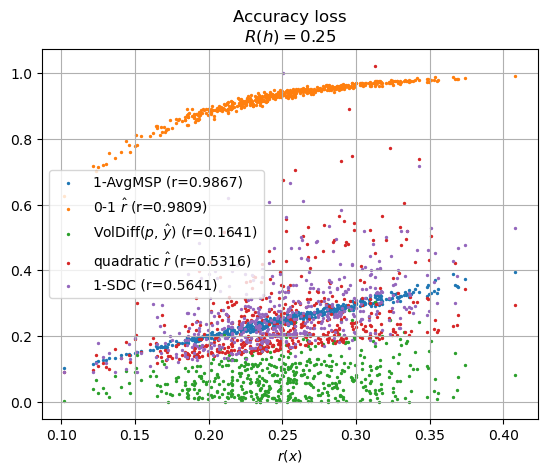

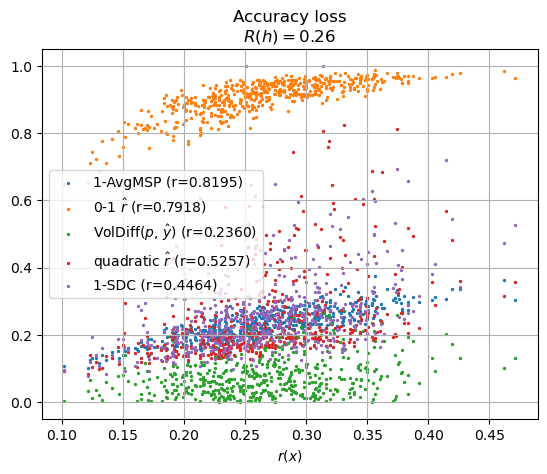

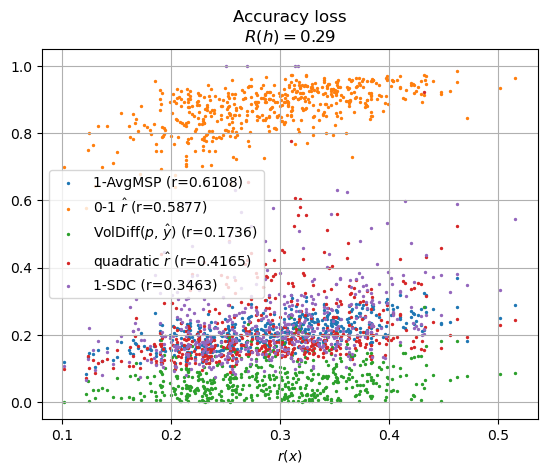

In [5]:
for scale in [0.0, 0.1, 0.5, 1.0]:
    hatPy, hatPyi, h = get_hatPs_h(scale)

    plot_accuracy_loss(h, Px, Py, hatPyi)

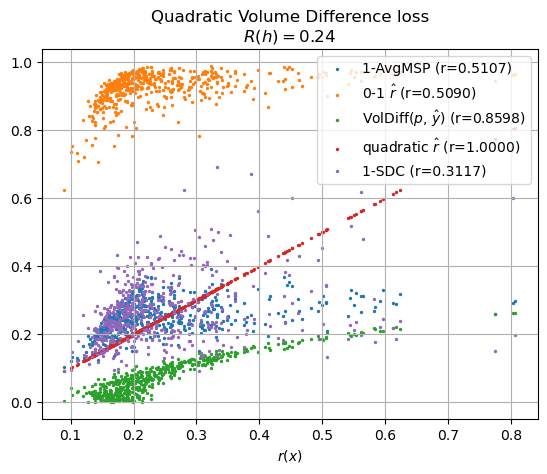

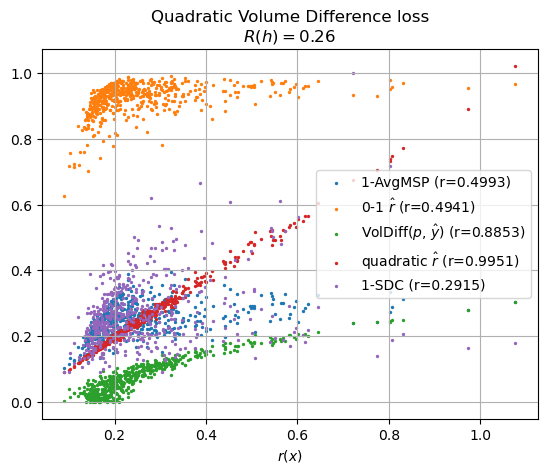

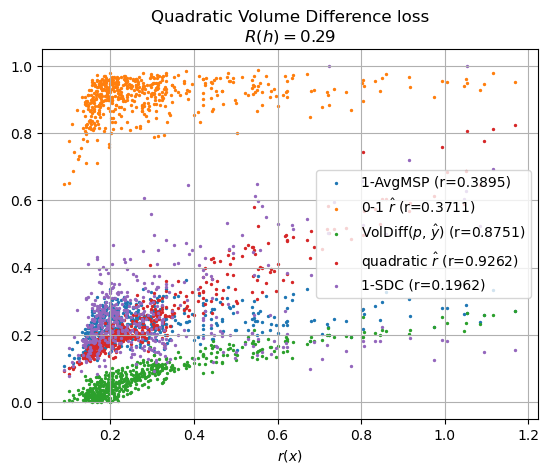

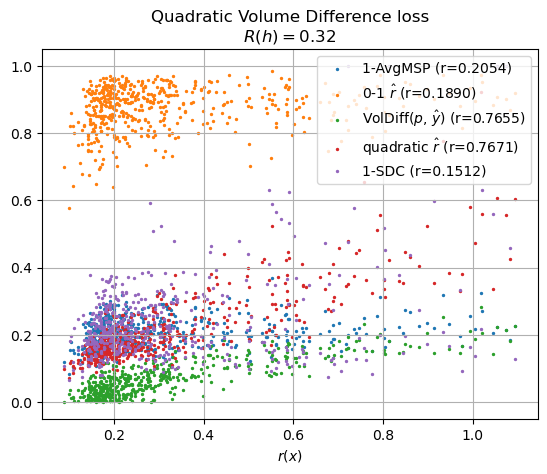

In [89]:
for scale in [0.0, 0.1, 0.5, 1.0]:
    hatPy, hatPyi, h = get_hatPs_h(scale)

    plot_quadvoldiff_loss(h, Px, Py, hatPyi)

## Max Dice model

The model is constructed as it were trained to minimize the dice loss. Its output is the segmentation that maximizes $\sum_y \hat{p}(y|x) DSC(y,\hat{y})$.

In [5]:
Y = list(range(2**9))

y_true = lambda x: np.argmax(Py[x])

def dice_loss(y, y_hat):
    if y == 0:
        if y_hat == 0:
            return 0
        else:
            return 1
    else:
        return 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum() + 1)

AllDiceLosses = np.array([np.array([dice_loss(y1, y2) for y2 in Y]) for y1 in Y])

def get_hatPs_h(scale=0.5):
    # pixel-level probability is predicted with a gaussian noise at the logits
    def hatpyi(x):
        z = sp.special.logit(Pyi[x])
        zhat = np.random.RandomState(x).normal(z, scale=scale)
        return sp.special.expit(zhat)

    # I think the following is more efficient, but I'm not risking it now
    # def pyhat(y, x):
    #     return np.abs((1-int2img(y)) - pyihat(x)).prod()

    hatPyi = [hatpyi(x) for x in np.arange(2**9)]
    hatPy = [np.array([np.where(int2img(y), pyi, 1 - pyi).prod() for y in np.arange(2**9)]) for pyi in hatPyi]

    # precompute the risk associated to each y given x
    Ryhat_dice = np.array([AllDiceLosses @ hatPy[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

    # model minimizes the DICE loss, i.e., picks the target with the lowest
    # predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
    h = lambda x: np.argmin(Ryhat_dice[x])
    
    return hatPy, hatPyi, h

## Losses

In [7]:
loss = lambda y, y_hat: 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum()+1e-3)
hatPy, hatPyi, h = get_hatPs_h(0.5)

r = get_true_conditional_risk(loss, Py, h)

R_x = np.vectorize(r)(X)

expected_risk_X = R_x * Px[X]
expected_risk_X.shape

(511,)

In [8]:
from src.risks import rc_curve

risks, coverages = rc_curve(-R_x, h, Px, Py, loss)

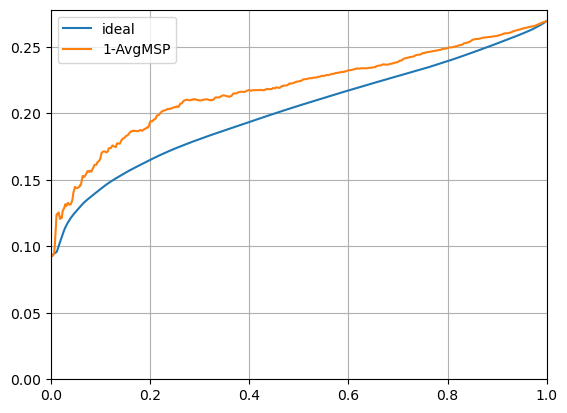

In [9]:
risks, coverages = rc_curve(-R_x, h, Px, Py, loss)
plt.plot(coverages, risks, label="ideal")

risks, coverages = rc_curve(-np.vectorize(get_avg_msp_rhat(h, Pyi))(X), h, Px, Py, loss)
plt.plot(coverages, risks, label="1-AvgMSP")

ylim = plt.ylim()
plt.ylim(0, ylim[1])
plt.xlim(0, 1)
plt.grid()
plt.legend()
plt.show()

In [66]:
from src.risks import expected_risk

%time expected_risk(h, Px, Py, loss)

CPU times: user 8.31 s, sys: 4.03 ms, total: 8.31 s
Wall time: 8.3 s


0.2919686920443712

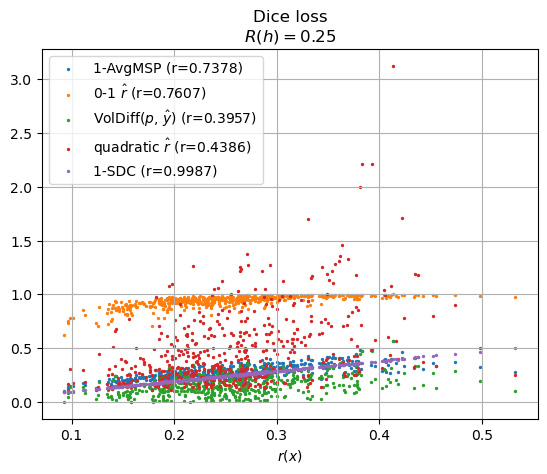

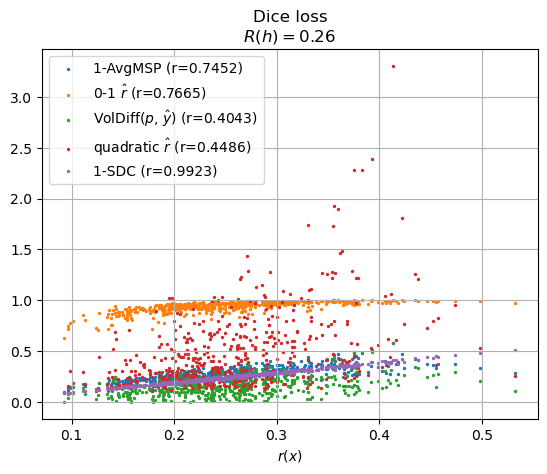

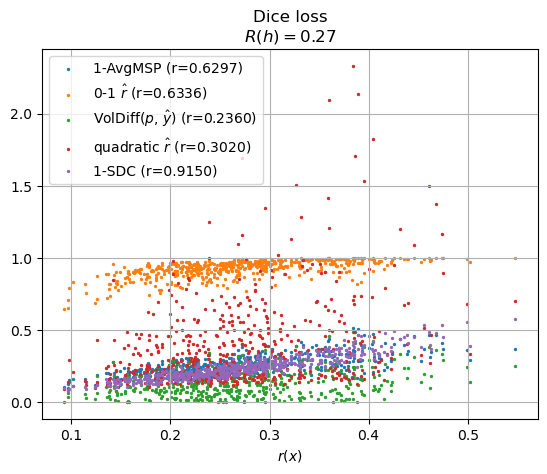

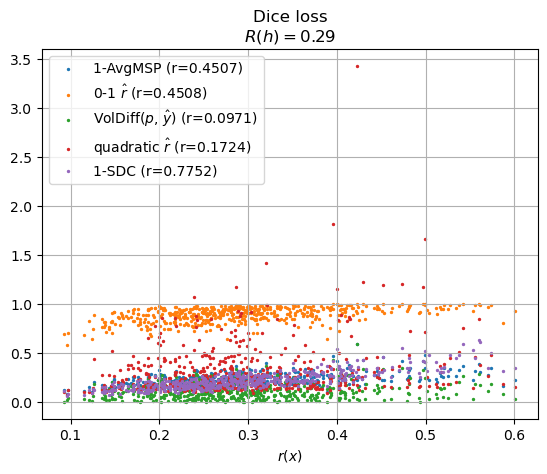

In [93]:
for scale in [0.0, 0.1, 0.5, 1.0]:
    hatPy, hatPyi, h = get_hatPs_h(scale)

    plot_dice_loss(h, Px, Py, hatPyi)

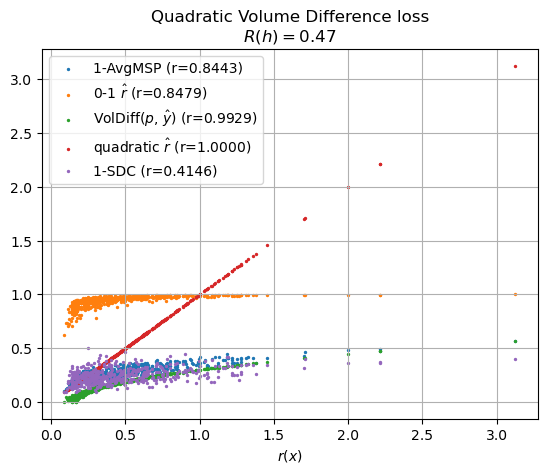

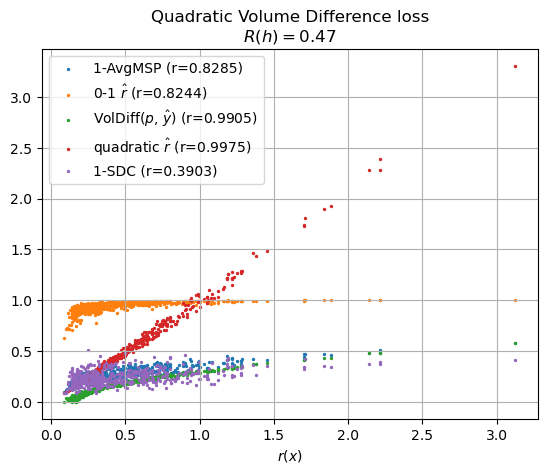

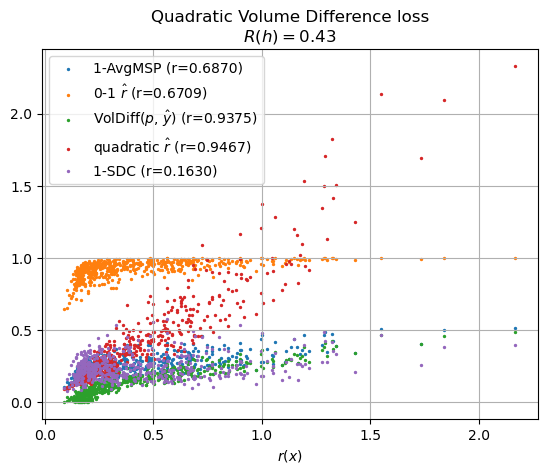

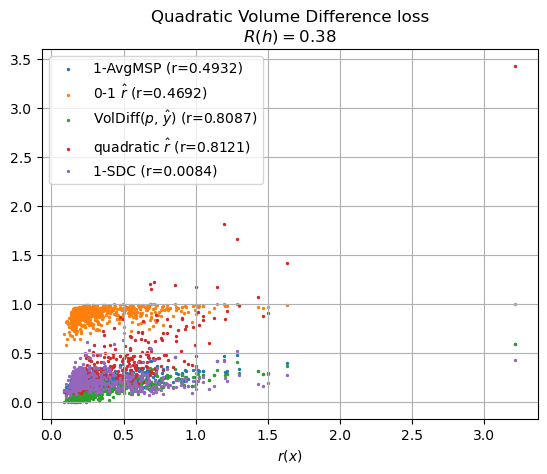

In [94]:
for scale in [0.0, 0.1, 0.5, 1.0]:
    hatPy, hatPyi, h = get_hatPs_h(scale)

    plot_quadvoldiff_loss(h, Px, Py, hatPyi)